# Overview

## Create the simulations

In [3]:
import numpy as np
from lucifex.fem import average_grid, cross_section_grid, mirror_grid
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz, Simulation
from lucifex.plt import (
    plot_colormap, plot_line, save_figure, plot_twin_lines,
    get_ipynb_file_name, set_ipynb_variable, plot_streamlines,
    plot_colormap_multifigure, plot_line_multifigure
)
from lucifex.solver import OptionsPETSc
from lucifex.utils.fenicsx_utils import extract_component_functions
from crocodil.dns.system_d import dns_system_d, SYSTEM_D_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 160)
NY = set_ipynb_variable('NY', 60)
ANIM = set_ipynb_variable('ANIM', False)

Ra = 600.0
PARAMS_PHYSICAL = SYSTEM_D_REFERENCE.replace(
    Ra=Ra, Pe=Ra, Da=2.0, 
    l=0.05, 
    inflow=('gaussian', 3.0), 
    p_dOmega='left', 
    mirror=-1,
)

theta_buoy_opts = (True, False)
simulations: dict[bool, Simulation] = {}

for theta_buoy in theta_buoy_opts:
    simulations[theta_buoy] = dns_system_d(
        store_delta=STORE, 
        write_delta=WRITE, 
        dir_root=DIR_ROOT, 
        dir_uid=True,
    )(
        Nx=NX,
        Ny=NY,
        cell='quadrilateral',
        scaling='advective',
        **PARAMS_PHYSICAL,
        theta_buoy=theta_buoy,
        dt_max=0.025,
        courant_adv=None,
        courant_diff=None,
        courant_reac=None,
        c_stabilization=None,
        theta_stabilization=None,
        c_limits=True,
        theta_limits=True, 
        flow_petsc=OptionsPETSc(
            ksp_type='preonly', 
            pc_type='lu', 
            pc_factor_mat_solver_type='mumps',
            blocked=False,
            
        ),
        diagnostic=True,
    )

## Run the simulations

In [ ]:
n_stop = set_ipynb_variable('N_STOP', 100)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

for theta_buoy, sim in simulations.items():
    sim = simulations[theta_buoy]
    run(sim, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
    if WRITE: 
        xdmf_to_npz(sim, delete_xdmf=False)
    else:
        write(sim.parameters, sim.parameter_file, sim.dir_path, mode='w')

## Physical diagnostics

### Vertical velocity component

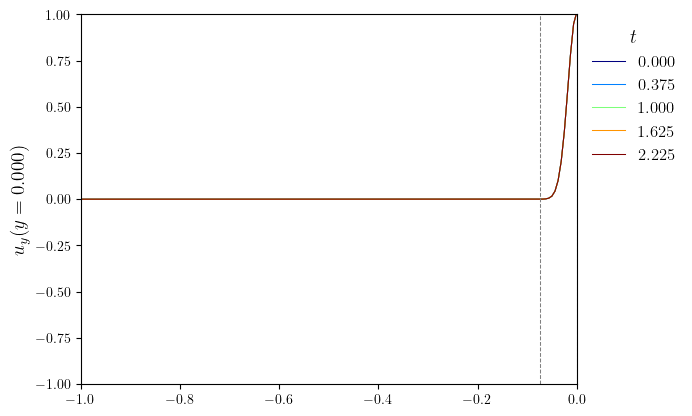

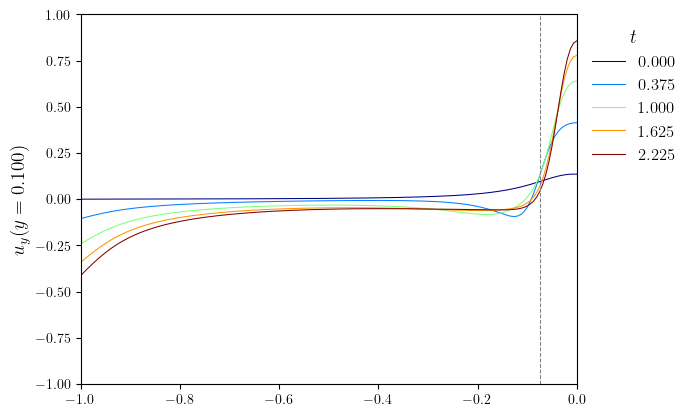

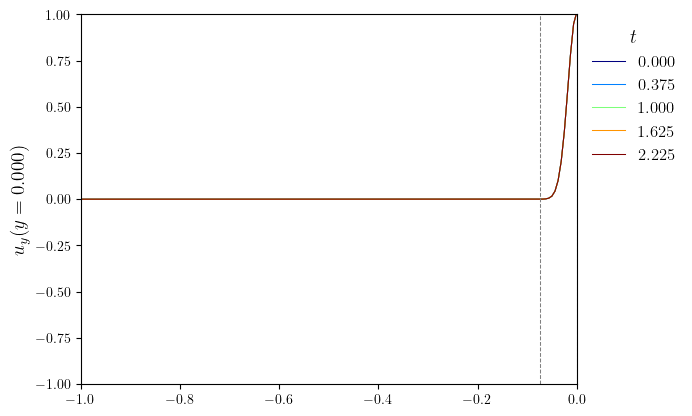

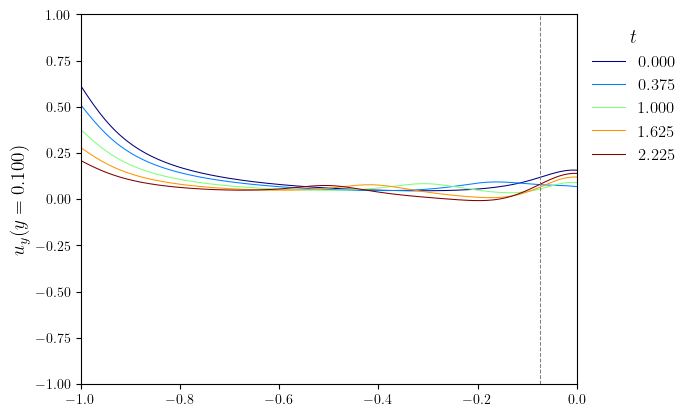

In [6]:
time_indices = (*[int(i * n_stop) for i in (0, 0.25, 0.5, 0.75)], -1)
y_cs_targets = (0, 0.1)

vline_kws = dict(
    linestyles='dashed', linewidths=0.75, colors='gray',
)

for theta_buoy, sim in simulations.items():
    u, In, Lx, Ll, xInflow = sim['u', 'In', 'Lx', 'Ll', 'xInflow']
    for y_cs_targ in y_cs_targets:
        uy_lines = []
        t_labels = []
        for i in time_indices:
            uxi, uyi = extract_component_functions(('P', 1), u.get_series_item(i))
            uyi_grid, y_cs  = cross_section_grid(uyi, 'y', target=y_cs_targ)
            uy_lines.append(uyi_grid)
            t_labels.append(f'{u.time_series[i]:.3f}')

        fig, ax = plot_line(
            uy_lines,
            cyc='jet',
            legend_labels=t_labels,
            legend_title='$t$',
            y_label=f'$u_y(y={y_cs:.3f})$',
        )
        y_lims = (-In, In)
        x_lims = Lx
        ax.vlines(xInflow, *y_lims, **vline_kws)
        ax.set_xlim(*x_lims)
        ax.set_ylim(*y_lims)

### Solutal and thermal flux

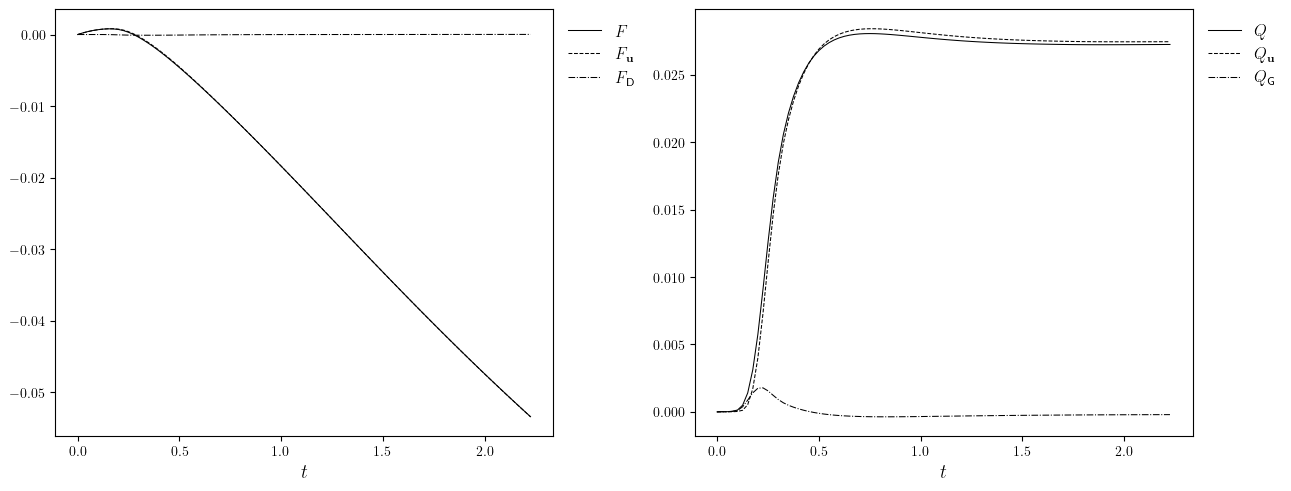

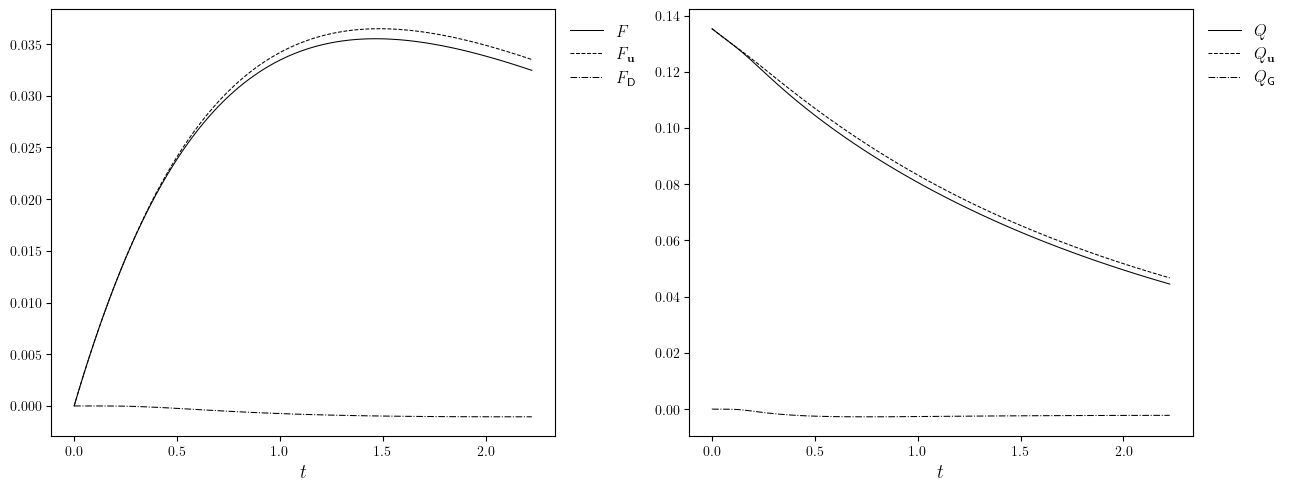

: 

In [ ]:
line_kws = dict(
    x_label='$t$',
    cyc='black',
)

for theta_buoy, sim in simulations.items():
    f, q = sim['f', 'q']
    f, *_ = f.split()
    q, *_  = q.split()
    mfig, *_ = plot_line_multifigure(n_cols=2)(
        [
            [(f.time_series, [np.sum(i) for i in f.value_series]), (f.time_series, f.value_series)], 
            [(q.time_series, [np.sum(i) for i in q.value_series]), (q.time_series, q.value_series)],
        ],
        cyc='black',
        legend_labels=[
            ['$F$', '$F_{\mathbf{u}}$', '$F_{\mathsf{D}}$'],
            ['$Q$', '$Q_{\mathbf{u}}$', '$Q_{\mathsf{G}}$'],
        ],
        x_label='$t$',
    )

## Visualization

### Concentration, temperature and saturation

In [7]:
time_indices = (*[int(i * n_stop) for i in (0, 0.25, 0.5)], -1)
mirror = PARAMS_PHYSICAL['mirror']

if mirror:
    mirrored = lambda u, rescale=1: mirror_grid(u, 'x', rescale)
else:
    mirrored = lambda u, *_: u

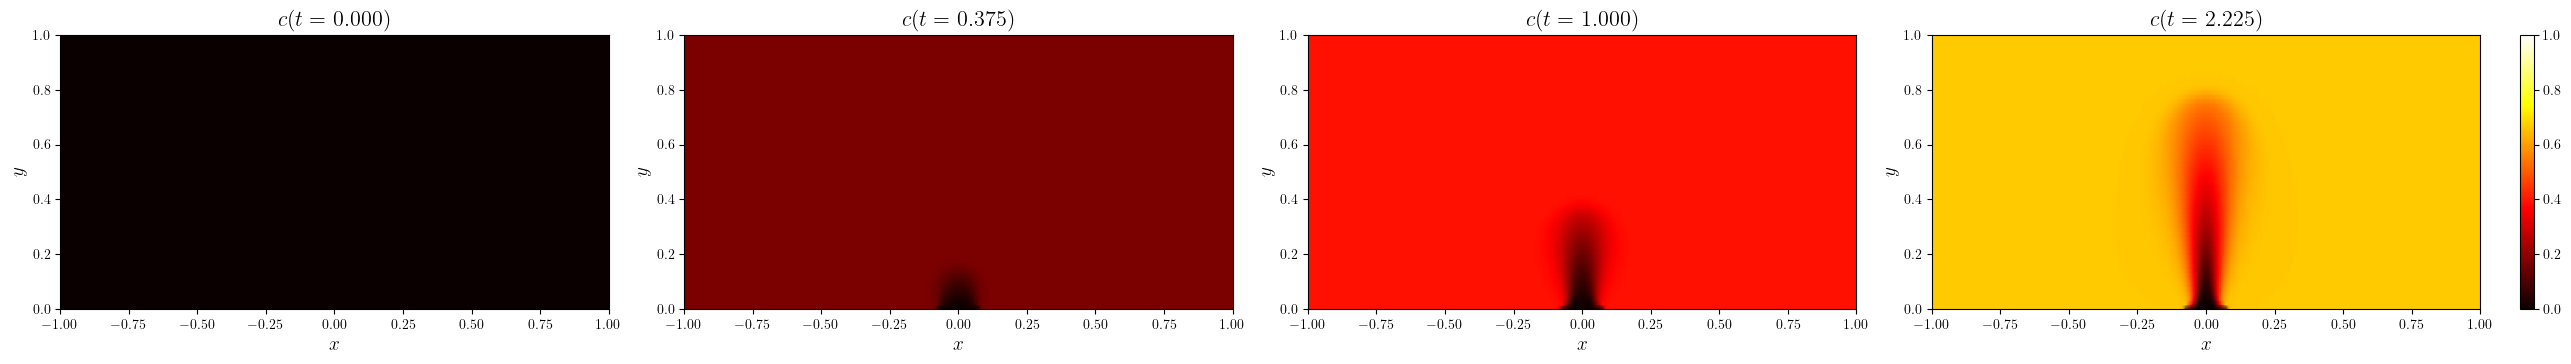

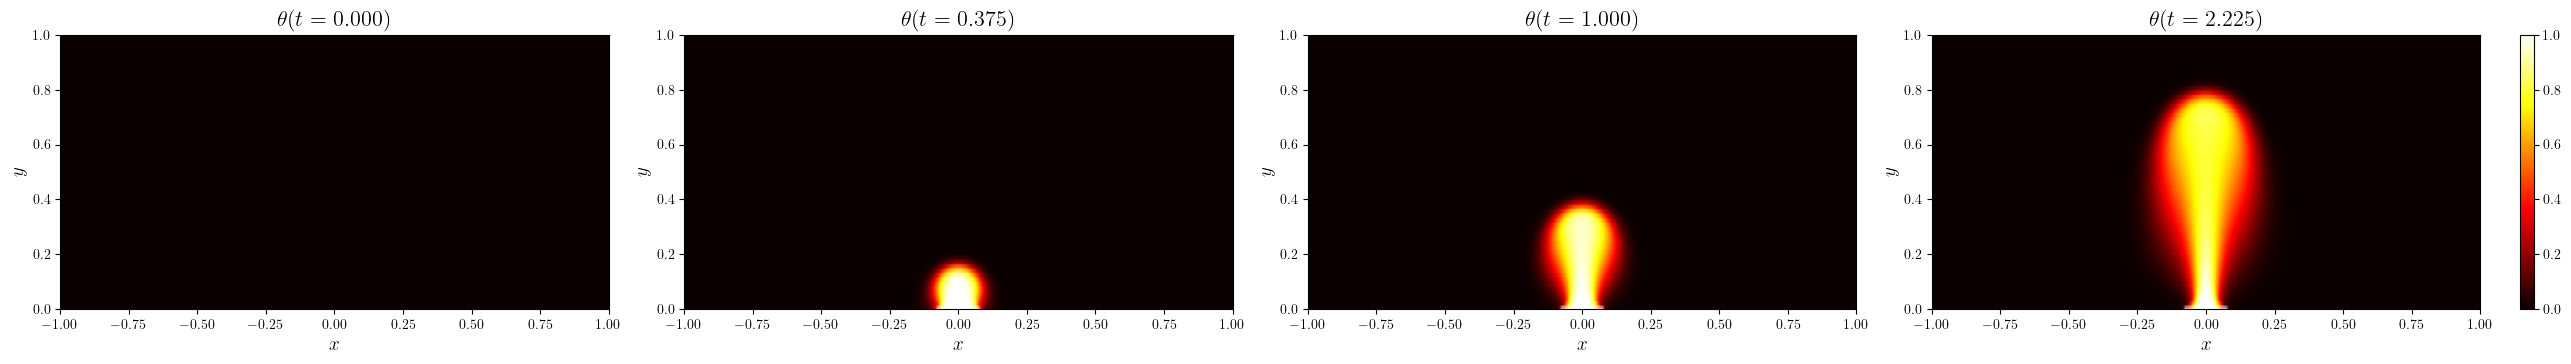

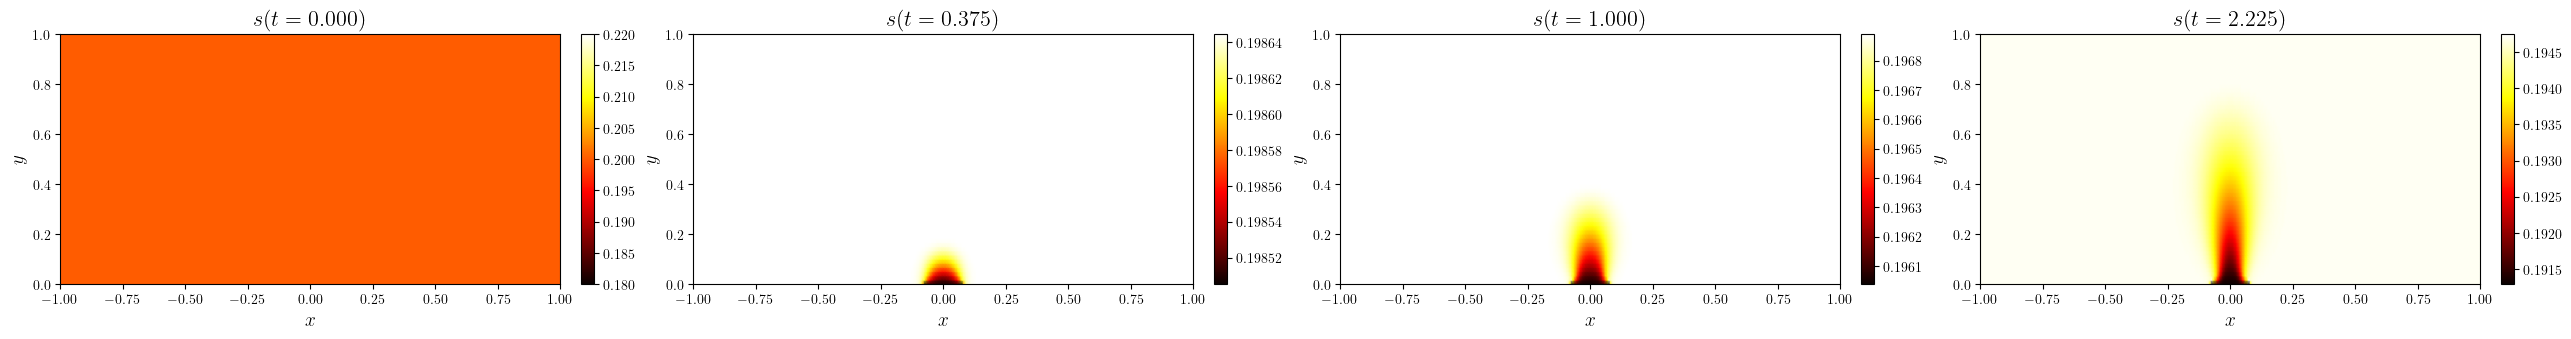

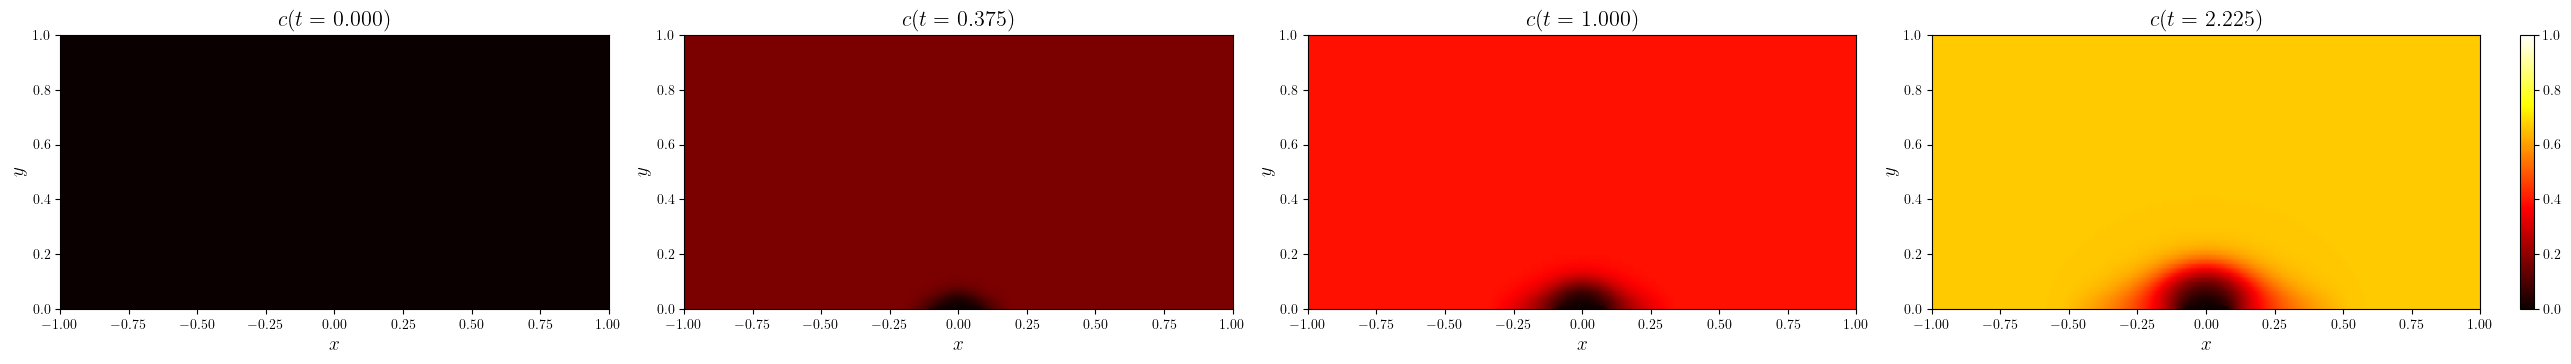

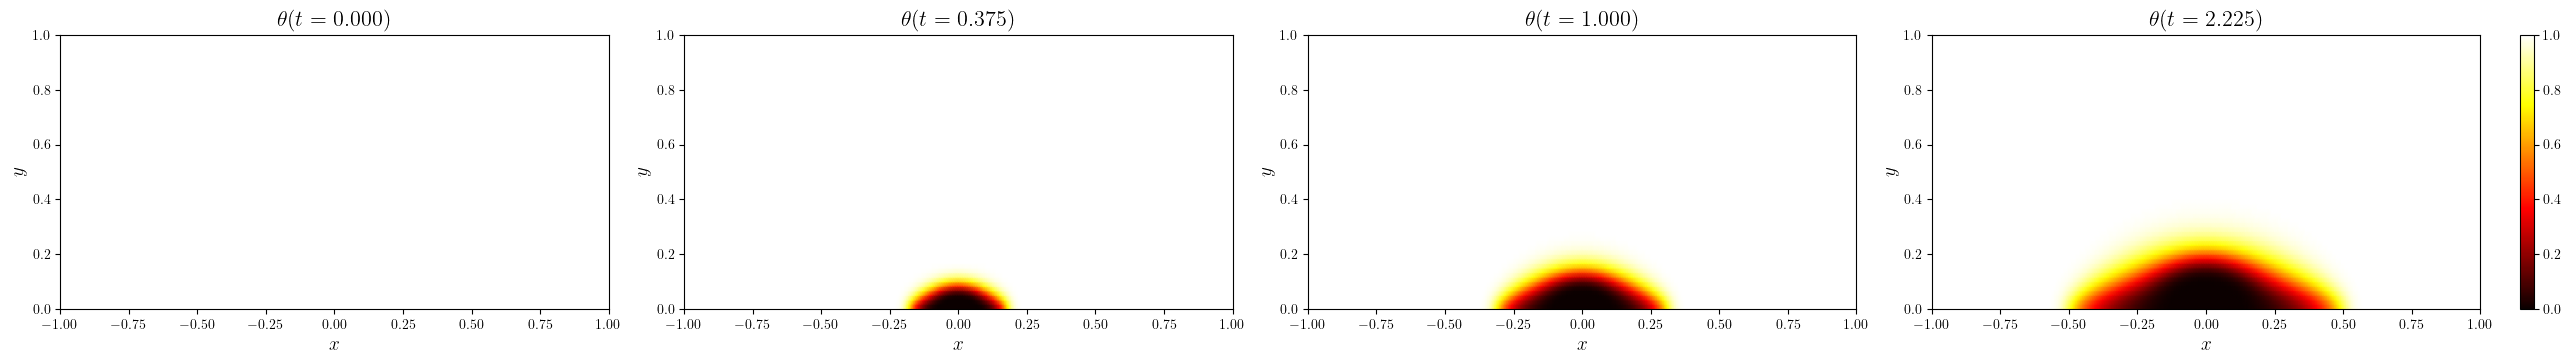

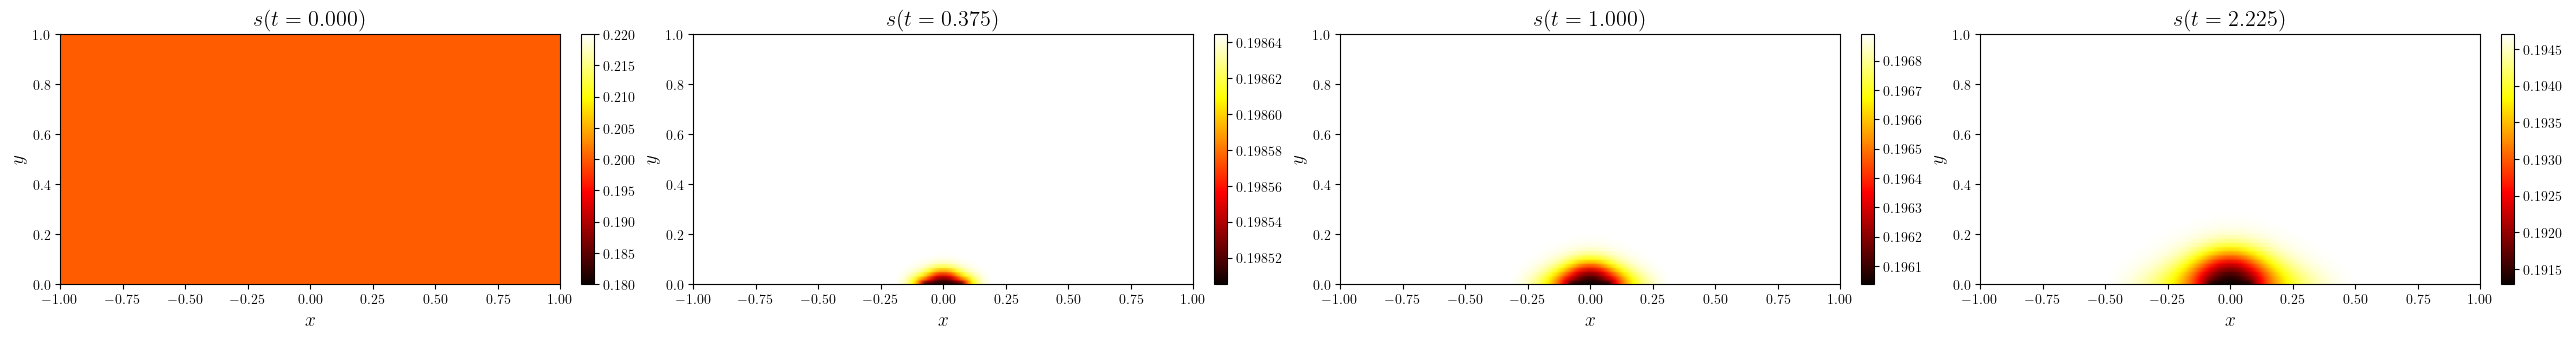

In [11]:
for theta_buoy, sim in simulations.items():
    s, c, theta = sim['s', 'c', 'theta']
    sim = simulations[theta_buoy]
    mfig_c, *_ = plot_colormap_multifigure(n_cols=len(time_indices), cbars=(0, 1))(
        [mirrored(c.series[i]) for i in time_indices],
        cmap='hot',
        title=[f'$c(t={c.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'theta_buoy={theta_buoy}_c(t)', sim.dir_path, prefix=False)(mfig_c)
    mfig_theta, *_ = plot_colormap_multifigure(n_cols=len(time_indices), cbars=(0, 1))(
        [mirrored(theta.series[i]) for i in time_indices],
        cmap='hot',
        title=[f'$\\theta(t={theta.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'theta_buoy={theta_buoy}_theta(t)', sim.dir_path, prefix=False)(mfig_theta)
    mfig_s, *_ = plot_colormap_multifigure(n_cols=len(time_indices), cbars=True)(
        [mirrored(s.series[i]) for i in time_indices],
        cmap='hot',
        title=[f'$s(t={s.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'theta_buoy={theta_buoy}_s(t)', sim.dir_path, prefix=False)(mfig_s)

### Pressure, streamlines and velocity components

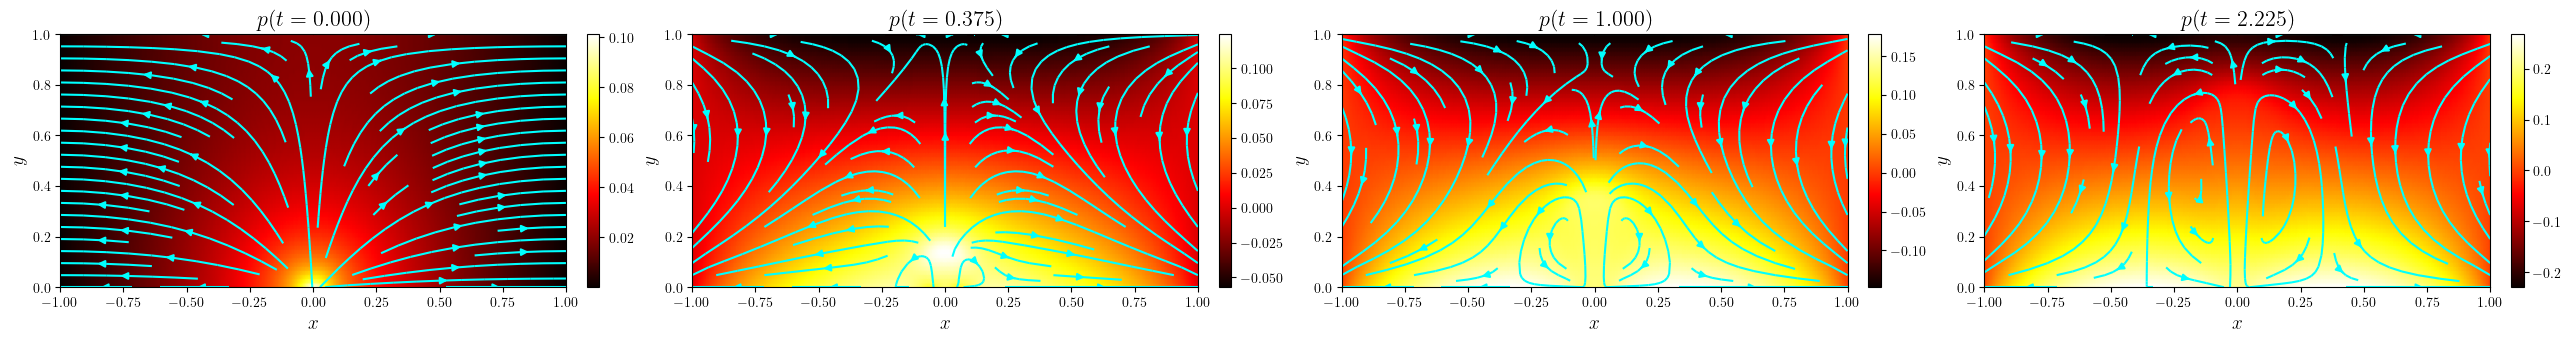

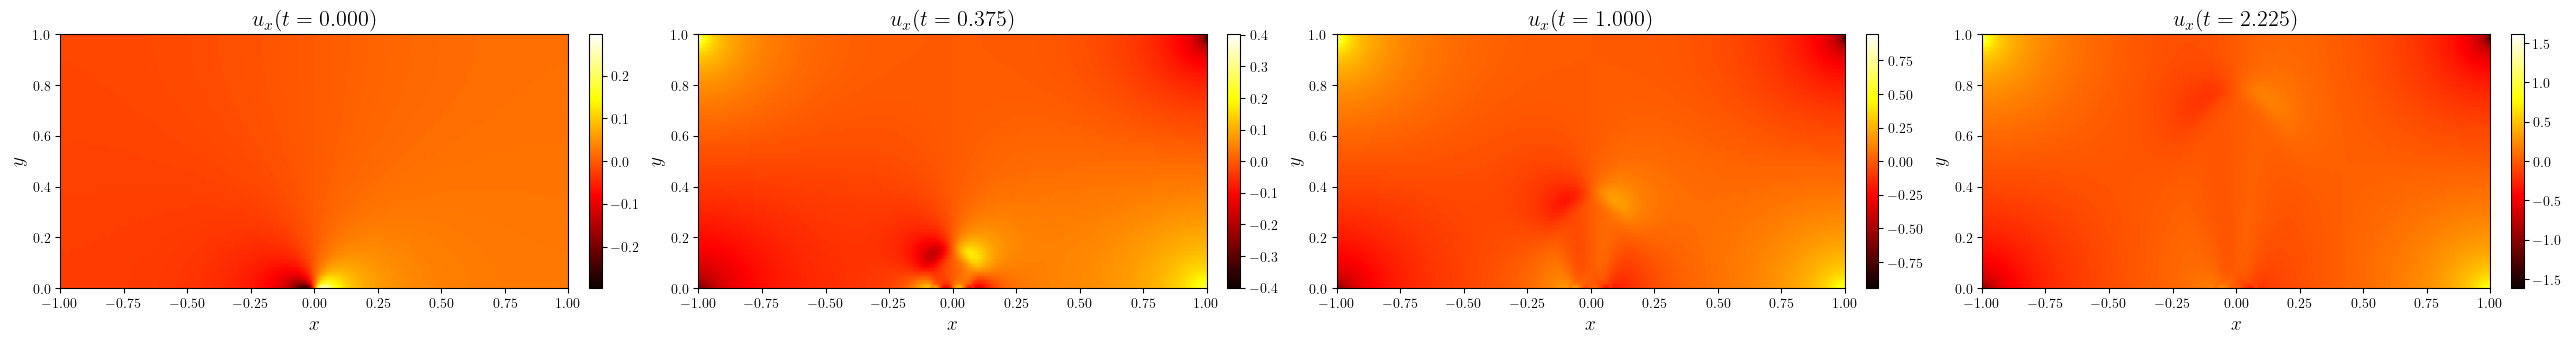

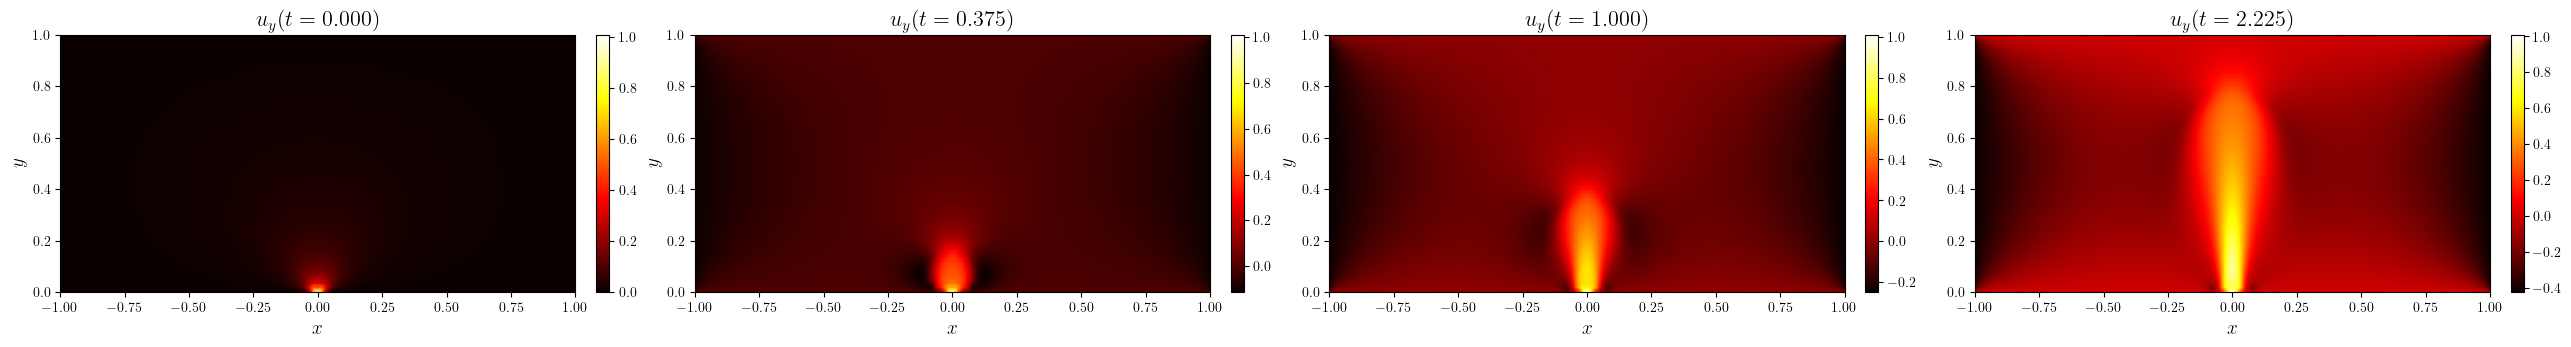

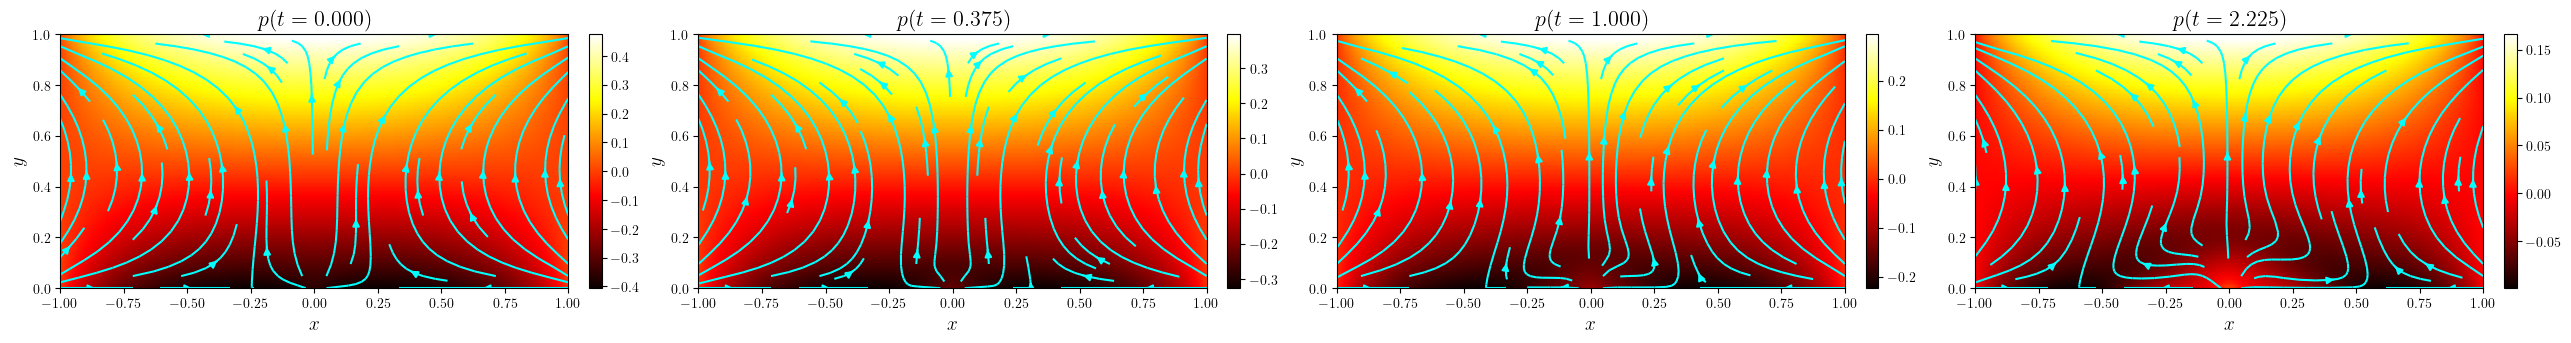

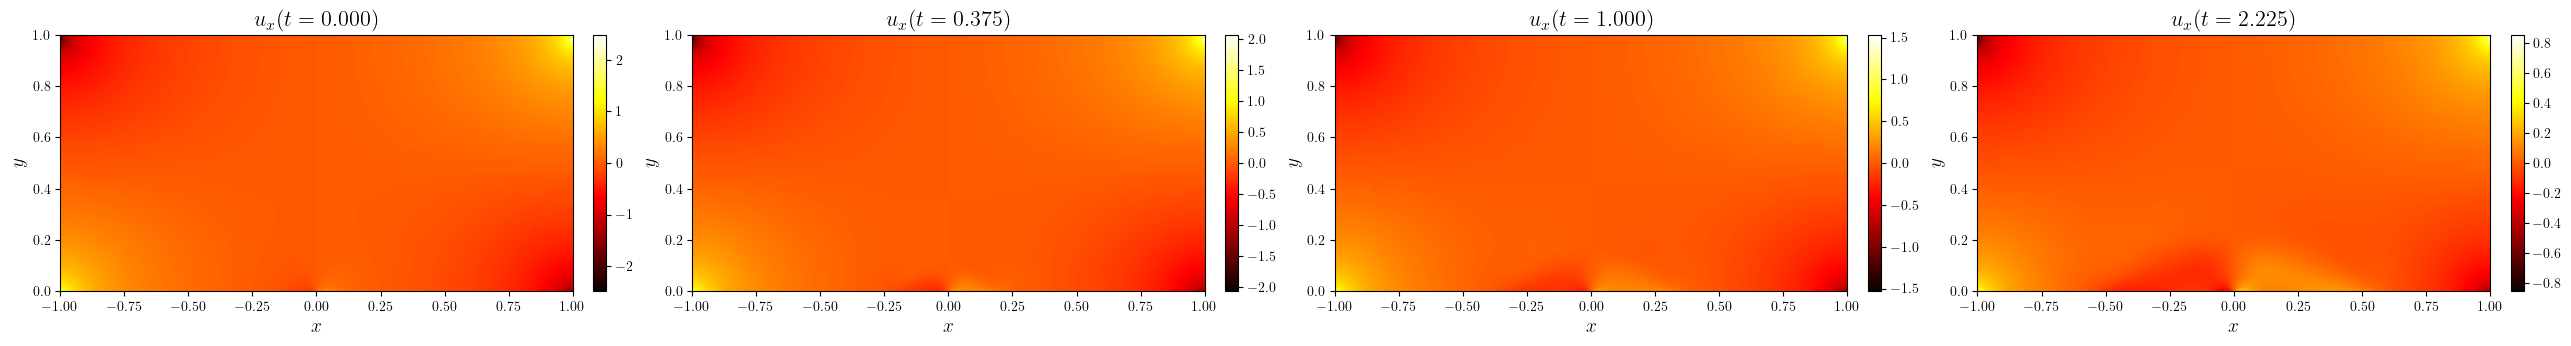

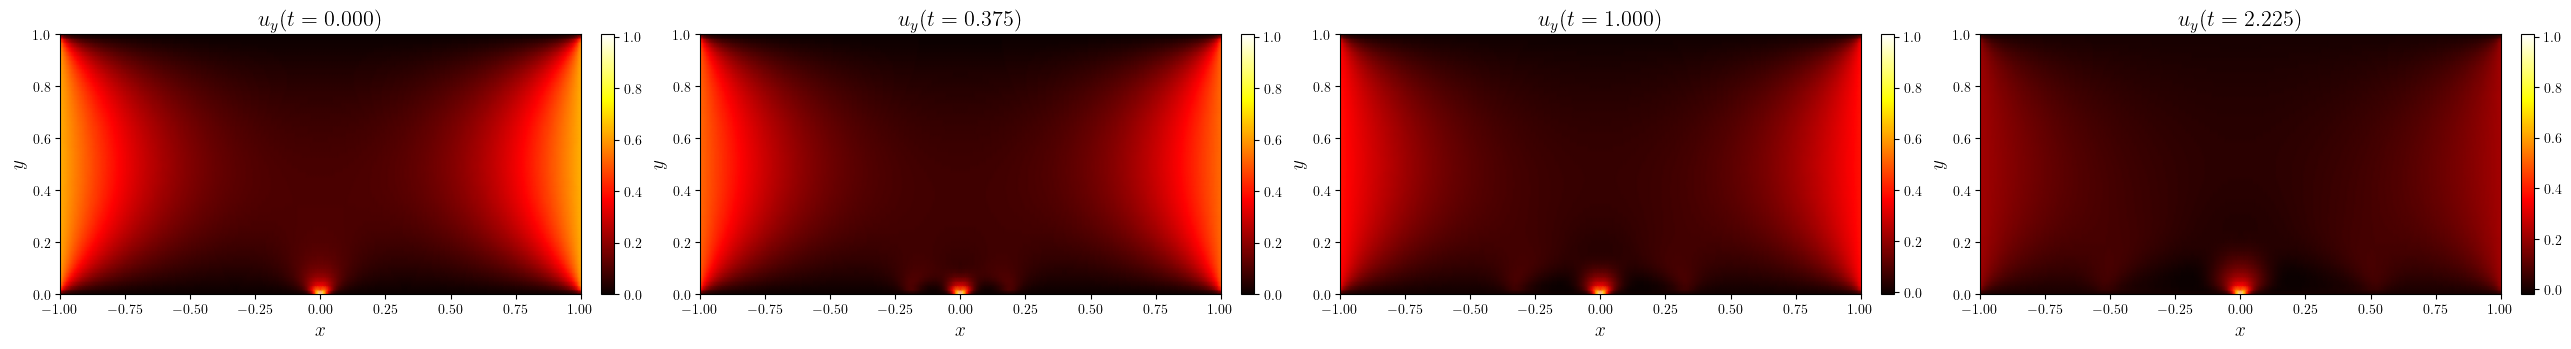

In [12]:
for theta_buoy, sim in simulations.items():
    u, p = sim['u', 'p']
    mfig_p, axs_p, _ = plot_colormap_multifigure(n_cols=len(time_indices), cbars=True)(
        [mirrored(p.get_series_item(i)) for i in time_indices],
        title=[f'$p(t={p.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'theta_buoy={theta_buoy}_p(t)_streamlines', sim.dir_path, prefix=False)(mfig_p)
    ux, uy = [], []
    for i, ax in zip(time_indices, axs_p):
        uxi, uyi = extract_component_functions(('P', 1), u.get_series_item(i))
        uxi, uyi = mirrored(uxi, -1), mirrored(uyi)
        plot_streamlines(mfig_p, ax, (uxi, uyi), density=0.75, color='cyan')
        ux.append(uxi)
        uy.append(uyi)
    mfig_ux, *_ = plot_colormap_multifigure(n_cols=len(time_indices), cbars=True)(
        ux,
        title=[f'$u_x(t={u.time_series[i]:.3f})$' for i in time_indices],
    )
    mfig_uy, *_ = plot_colormap_multifigure(n_cols=len(time_indices), cbars=True)(
        uy,
        title=[f'$u_y(t={u.time_series[i]:.3f})$' for i in time_indices],
    )